# Battery 불량 탐지 - EfficientNetB0 전이학습 (Transfer Learning)

**목표**: EfficientNetB0을 활용하여 배터리 불량을 탐지합니다.

**EfficientNet이란?**
- Google이 2019년에 발표한 모델 계열 (B0 ~ B7)
- 모델 크기, 해상도, 깊이를 균형 있게 조절하는 'Compound Scaling' 기법 사용
- ResNet50보다 파라미터 수가 적으면서도 정확도가 높습니다.

**ResNet50과 비교:**
| 항목 | ResNet50 | EfficientNetB0 |
|------|----------|----------------|
| 파라미터 수 | ~25M | ~5.3M |
| Top-1 정확도(ImageNet) | 76.0% | 77.1% |
| 속도 | 보통 | 빠름 |

**2단계 Fine-tuning 전략:**
- 1단계: EfficientNetB0 가중치 동결 -> 분류기만 학습
- 2단계: 상위 레이어 일부 동결 해제 -> 전체 미세조정

---
> **메모리**: tf.data 파이프라인 방식으로 RAM 부족 없이 실행됩니다.
> **CPU 환경**: EPOCHS를 3~5로 줄여 테스트해 보세요.

In [1]:
# ==============================================================
# [셀 1] 라이브러리 임포트 및 경로 설정
# ==============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from glob import glob

ROOT      = os.path.join(os.getcwd(), 'dataset', 'battery_subset_binary_train10000')
IMAGE_DIR = os.path.join(ROOT, 'images')
MODEL_DIR = os.path.join(os.getcwd(), 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS_1   = 5
EPOCHS_2   = 5

print('데이터셋 루트:', ROOT)
print('모델 저장 폴더:', MODEL_DIR)

데이터셋 루트: d:\DeepLearning\dataset\battery_subset_binary_train10000
모델 저장 폴더: d:\DeepLearning\model


In [2]:
# ==============================================================
# [셀 2] CSV 로드 + tf.data 파이프라인 구성 (EfficientNet 전용)
# ==============================================================
# [메모리 절약] tf.data 파이프라인 사용
#   - 이미지를 RAM에 한꺼번에 올리지 않고 배치 단위로 읽습니다.
#
# EfficientNet 전처리 특징:
#   - preprocess_input(): 픽셀값을 0~255 -> -1~1로 변환
#     (ResNet의 채널별 평균 빼기와는 다른 방식)
#   - 반드시 EfficientNet용 preprocess_input을 사용!
# ==============================================================

from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

# CSV 로드 및 경로 생성
train_df = pd.read_csv(os.path.join(ROOT, 'train.csv'))
valid_df  = pd.read_csv(os.path.join(ROOT, 'valid.csv'))



for df in [train_df, valid_df]:
    df['new_relative_path'] = df['new_relative_path'].str.replace('\\', '/', regex=False)
    df['image_path']   = df['new_relative_path'].apply(lambda x: os.path.join(ROOT, x))
    df['image_exists'] = df['image_path'].apply(lambda p: os.path.exists(p) and os.path.getsize(p) > 0)
    df['label_num']    = df['binary_label'].map({'normal': 0, 'defect': 1})

train_df = train_df[train_df['image_exists']].copy()
valid_df  = valid_df[valid_df['image_exists']].copy()

print(f'train: {len(train_df)}장, valid: {len(valid_df)}장')

train_paths  = train_df['image_path'].tolist()
train_labels = train_df['label_num'].tolist()
valid_paths  = valid_df['image_path'].tolist()
valid_labels = valid_df['label_num'].tolist()


def load_and_preprocess_effnet(path, label):
    """
    EfficientNet 전용 이미지 로더.
    effnet_preprocess: 픽셀 0~255 -> -1~1 정규화
    """
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = effnet_preprocess(img)  # EfficientNet 전용 정규화 (-1~1)
    return img, label


# tf.data 파이프라인 구성
train_dataset = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .shuffle(len(train_paths), seed=42)
    .map(load_and_preprocess_effnet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
valid_dataset = (
    tf.data.Dataset.from_tensor_slices((valid_paths, valid_labels))
    .map(load_and_preprocess_effnet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

sample_imgs, sample_lbls = next(iter(train_dataset))
print('샘플 배치 shape:', sample_imgs.shape)
print('라벨 분포 - train normal:', train_labels.count(0), '/ defect:', train_labels.count(1))

train: 7982장, valid: 1997장
샘플 배치 shape: (16, 224, 224, 3)
라벨 분포 - train normal: 4000 / defect: 3982


In [3]:
# ==============================================================
# [셀 3] EfficientNetB0 모델 구성 (Transfer Learning)
# ==============================================================
# EfficientNet 구성의 핵심:
#
#   MBConv(Mobile Inverted Bottleneck Conv): EfficientNet의 핵심 블록
#     MobileNet의 깊이별 분리 합성곱을 개선한 구조
#   SE(Squeeze-and-Excitation): 채널별 중요도를 학습하는 어텐션 메커니즘
#
#   include_top=False: 1000 클래스 분류 레이어 제외
#   pooling='avg'    : Global Average Pooling (GAP) 적용
#
# GAP이란?
#   - (H, W, C) 특징 맵의 H, W를 평균 내어 (C,) 벡터로 만듦
#   - Flatten보다 파라미터 수가 적고 과적합이 적음
# ==============================================================

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# EfficientNetB0 베이스 로드 (첫 실행 시 ~30MB 다운로드)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# 1단계: 전체 동결
base_model.trainable = False

# 분류 헤드 추가
x = base_model.output
x = Dense(128, activation='relu', name='classifier_dense')(x)
x = Dropout(0.3, name='classifier_dropout')(x)
output = Dense(1, activation='sigmoid', name='classifier_output')(x)

model_effnet = Model(inputs=base_model.input, outputs=output)

print(f'전체 레이어 수: {len(model_effnet.layers)}')
print(f'전체 파라미터: {model_effnet.count_params():,}')
print(f'(ResNet50 ~25M 대비 {model_effnet.count_params()/1e6:.1f}M으로 훨씬 가벼움)')

전체 레이어 수: 242
전체 파라미터: 4,213,668
(ResNet50 ~25M 대비 4.2M으로 훨씬 가벼움)


In [4]:
# ==============================================================
# [셀 4] 1단계 학습: 분류기(헤드)만 학습
# ==============================================================
# 1단계에서는 EfficientNetB0 가중치를 완전히 동결하고
# 우리가 추가한 Dense + Dropout + Output 레이어만 학습합니다.
#
# EfficientNet 주의사항:
#   - BatchNormalization 레이어가 많으므로 Fine-tuning 시
#     학습률을 반드시 낮게 유지해야 안정적입니다.
# ==============================================================

model_effnet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

checkpoint_1 = ModelCheckpoint(
    os.path.join(MODEL_DIR, 'battery_efficientnet_stage1_best.keras'),
    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)
early_stop_1 = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

print('=== 1단계 학습: 분류기(헤드)만 학습 ===')
history_1 = model_effnet.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS_1,
    callbacks=[checkpoint_1, early_stop_1]
)

print('\n1단계 완료! 검증 정확도:', max(history_1.history['val_accuracy']))

=== 1단계 학습: 분류기(헤드)만 학습 ===
Epoch 1/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9711 - loss: 0.0939
Epoch 1: val_accuracy improved from -inf to 0.98448, saving model to d:\DeepLearning\model\battery_efficientnet_stage1_best.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 311s 598ms/step - accuracy: 0.9711 - loss: 0.0939 - val_accuracy: 0.9845 - val_loss: 0.0725
Epoch 2/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.9835 - loss: 0.0675
Epoch 2: val_accuracy did not improve from 0.98448
499/499 ━━━━━━━━━━━━━━━━━━━━ 279s 558ms/step - accuracy: 0.9835 - loss: 0.0675 - val_accuracy: 0.9845 - val_loss: 0.0559
Epoch 3/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9865 - loss: 0.0533
Epoch 3: val_accuracy did not improve from 0.98448
499/499 ━━━━━━━━━━━━━━━━━━━━ 273s 546ms/step - accuracy: 0.9865 - loss: 0.0533 - val_accuracy: 0.9845 - val_loss: 0.0671
Epoch 4/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9871 - loss: 0.0484
Epoch 4: val_accuracy did not

In [5]:
# ==============================================================
# [셀 5] 2단계 Fine-tuning: 상위 레이어 동결 해제
# ==============================================================
# EfficientNetB0의 Fine-tuning 전략:
#   - EfficientNetB0 총 레이어: 약 238개
#   - 하위 레이어: 기초적인 특징 (엣지, 색상) -> 동결 유지
#   - 상위 레이어: 복잡한 패턴 -> 해제하여 배터리 데이터에 적응
#   - BatchNorm은 항상 동결 (안정성)
# ==============================================================

from tensorflow.keras.layers import BatchNormalization

UNFREEZE_FROM = 150

for layer in model_effnet.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
    elif model_effnet.layers.index(layer) >= UNFREEZE_FROM:
        layer.trainable = True

# Fine-tuning 시 매우 낮은 학습률
# EfficientNet은 ResNet보다 BatchNorm이 많아 더 낮은 lr 권장
model_effnet.compile(
    optimizer=Adam(learning_rate=0.00005),  # 5e-5
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f'학습 가능 레이어: {sum(1 for l in model_effnet.layers if l.trainable)} / {len(model_effnet.layers)}')

checkpoint_2 = ModelCheckpoint(
    os.path.join(MODEL_DIR, 'battery_efficientnet_finetune_best.keras'),
    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)
early_stop_2 = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

print('=== 2단계 Fine-tuning 시작 ===')
history_2 = model_effnet.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS_2,
    callbacks=[checkpoint_2, early_stop_2]
)

print('\n2단계 완료! 검증 정확도:', max(history_2.history['val_accuracy']))

학습 가능 레이어: 74 / 242
=== 2단계 Fine-tuning 시작 ===
Epoch 1/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.9829 - loss: 0.0649
Epoch 1: val_accuracy improved from -inf to 0.98448, saving model to d:\DeepLearning\model\battery_efficientnet_finetune_best.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 373s 715ms/step - accuracy: 0.9829 - loss: 0.0649 - val_accuracy: 0.9845 - val_loss: 0.0469
Epoch 2/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.9847 - loss: 0.0560
Epoch 2: val_accuracy improved from 0.98448 to 0.98648, saving model to d:\DeepLearning\model\battery_efficientnet_finetune_best.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 336s 672ms/step - accuracy: 0.9847 - loss: 0.0560 - val_accuracy: 0.9865 - val_loss: 0.0456
Epoch 3/5
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.9834 - loss: 0.0482
Epoch 3: val_accuracy did not improve from 0.98648
499/499 ━━━━━━━━━━━━━━━━━━━━ 340s 680ms/step - accuracy: 0.9835 - loss: 0.0482 - val_accuracy: 0.9850 - val_loss: 0.0462
Epoch 4/5
4

125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 452ms/step - accuracy: 0.9914 - loss: 0.0309

=== 최종 검증 결과 (EfficientNetB0) ===
검증 손실: 0.0344
검증 정확도: 0.989

=== Confusion Matrix ===
[[981  19]
 [  3 994]]

=== Classification Report ===
              precision    recall  f1-score   support

      normal       1.00      0.98      0.99      1000
      defect       0.98      1.00      0.99       997

    accuracy                           0.99      1997
   macro avg       0.99      0.99      0.99      1997
weighted avg       0.99      0.99      0.99      1997



C:\Users\human-12\AppData\Local\Temp\ipykernel_21756\3144474123.py:54: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human-12\AppData\Local\Temp\ipykernel_21756\3144474123.py:54: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human-12\AppData\Local\Temp\ipykernel_21756\3144474123.py:55: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(MODEL_DIR, 'efficientnet_training_curve.png'), dpi=150)
C:\Users\human-12\AppData\Local\Temp\ipykernel_21756\3144474123.py:55: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(MODEL_DIR, 'efficientnet_training_curve.png'), dpi=150)
d:\DeepLearning\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.p

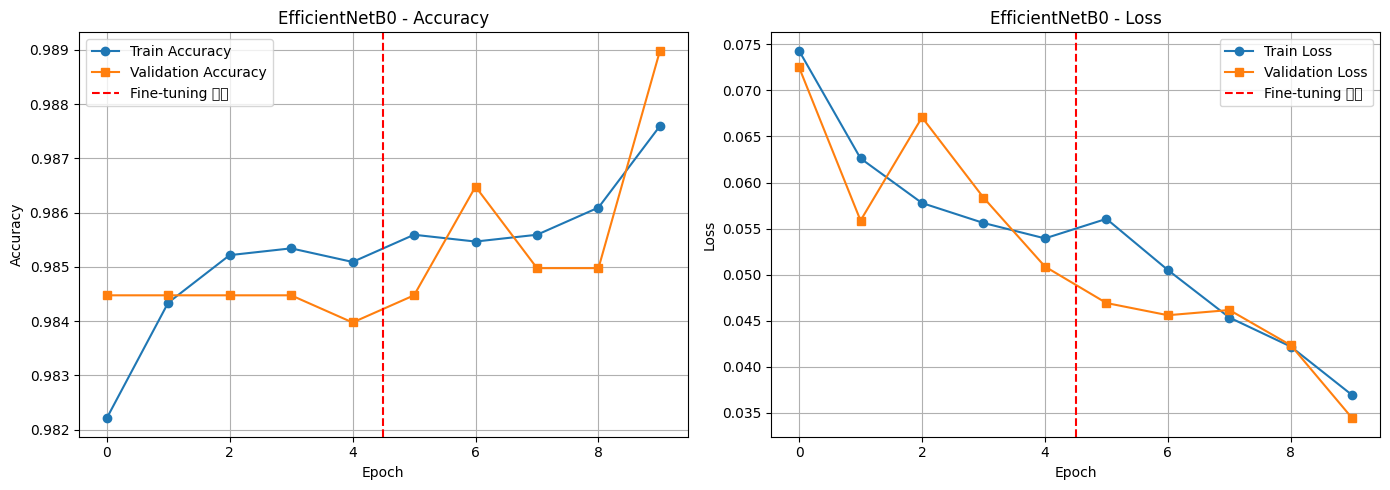

학습 곡선 저장 완료


In [6]:
# ==============================================================
# [셀 6] 최종 평가 및 시각화
# ==============================================================

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

loss, acc = model_effnet.evaluate(valid_dataset)
print('\n=== 최종 검증 결과 (EfficientNetB0) ===')
print('검증 손실:', round(loss, 4))
print('검증 정확도:', round(acc, 4))

# 배치 단위로 예측 수집
y_prob_list, y_true_list = [], []
for batch_imgs, batch_lbls in valid_dataset:
    preds = model_effnet.predict_on_batch(batch_imgs)
    y_prob_list.append(preds.reshape(-1))
    y_true_list.append(batch_lbls.numpy())

y_prob = np.concatenate(y_prob_list)
y_true = np.concatenate(y_true_list)
y_pred = (y_prob >= 0.5).astype(int)

print('\n=== Confusion Matrix ===')
print(confusion_matrix(y_true, y_pred))

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=['normal', 'defect']))

# 학습 곡선
acc_all     = history_1.history['accuracy']     + history_2.history['accuracy']
val_acc_all = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
loss_all    = history_1.history['loss']         + history_2.history['loss']
val_loss_all= history_1.history['val_loss']     + history_2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc_all,     label='Train Accuracy', marker='o')
axes[0].plot(val_acc_all, label='Validation Accuracy', marker='s')
axes[0].axvline(x=len(history_1.history['accuracy'])-0.5,
                color='red', linestyle='--', label='Fine-tuning 시작')
axes[0].set_title('EfficientNetB0 - Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(loss_all,     label='Train Loss', marker='o')
axes[1].plot(val_loss_all, label='Validation Loss', marker='s')
axes[1].axvline(x=len(history_1.history['loss'])-0.5,
                color='red', linestyle='--', label='Fine-tuning 시작')
axes[1].set_title('EfficientNetB0 - Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'efficientnet_training_curve.png'), dpi=150)
plt.show()
print('학습 곡선 저장 완료')

In [ ]:
# ==============================================================
# [셀 7] 모델 저장 + 모델별 비교 안내
# ==============================================================

save_path = os.path.join(MODEL_DIR, 'battery_efficientnet_final.keras')
model_effnet.save(save_path)
print('EfficientNetB0 최종 모델 저장 완료:', save_path)

print()
print('=' * 60)
print('모델별 특징 비교')
print('=' * 60)
print('모델           | 파라미터  | 특징')
print('-' * 60)
print('Custom CNN     | ~1M      | 처음부터 직접 학습, 이해하기 쉬움')
print('ResNet50       | ~25M     | 잔차 연결, 깊어도 안정적')
print('EfficientNetB0 | ~5.3M    | 파라미터 대비 정확도 가장 높음')
print('=' * 60)

EfficientNetB0 최종 모델 저장 완료: d:\DeepLearning\model\battery_efficientnet_final.keras

모델별 특징 비교
모델           | 파라미터  | 특징
------------------------------------------------------------
Custom CNN     | ~1M      | 처음부터 직접 학습, 이해하기 쉬움
ResNet50       | ~25M     | 잔차 연결, 깊어도 안정적
EfficientNetB0 | ~5.3M    | 파라미터 대비 정확도 가장 높음


: 